# 🎵 Визуализация на Мел-спектрограмите по Класове

В този ноутбук ще създадем "визуална галерия" на различни звукови класове от датасета ESC-50.
Целта е да разберем как звуците от реалния свят (като животни, природни явления и градски шумове) се превеждат на езика на компютърното зрение – 2D Мел-спектрограми.

Това ни помага да разберем защо Конволюционните невронни мрежи (CNN) са толкова успешни в аудио класификацията: те буквално разпознават "форми" и "текстури" в тези изображения.

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Пътища до оригиналните файлове
CSV_PATH = "../data/raw/Urban8k/UrbanSound8K.csv"
AUDIO_DIR = "../data/raw/Urban8k/*/"

# Зареждане на метаданните
df = pd.read_csv(CSV_PATH)
print(f"Общ брой файлове: {len(df)}")
print(f"Общ брой класове: {df['class'].nunique()}")

Общ брой файлове: 8732
Общ брой класове: 10


## Генериране на Галерията (Spectrogram Grid)

Ще изберем 16 разнообразни класа и ще визуализираме по един случаен запис от всеки.
Използваме `librosa.feature.melspectrogram` с параметрите, които избрахме за нашия модел (128 мел-ленти, максимална честота 8000 Hz).

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_32992/2424699161.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050)
/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/venv/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/Urban8k/*/*.wav/189982-0-0-30.wav'

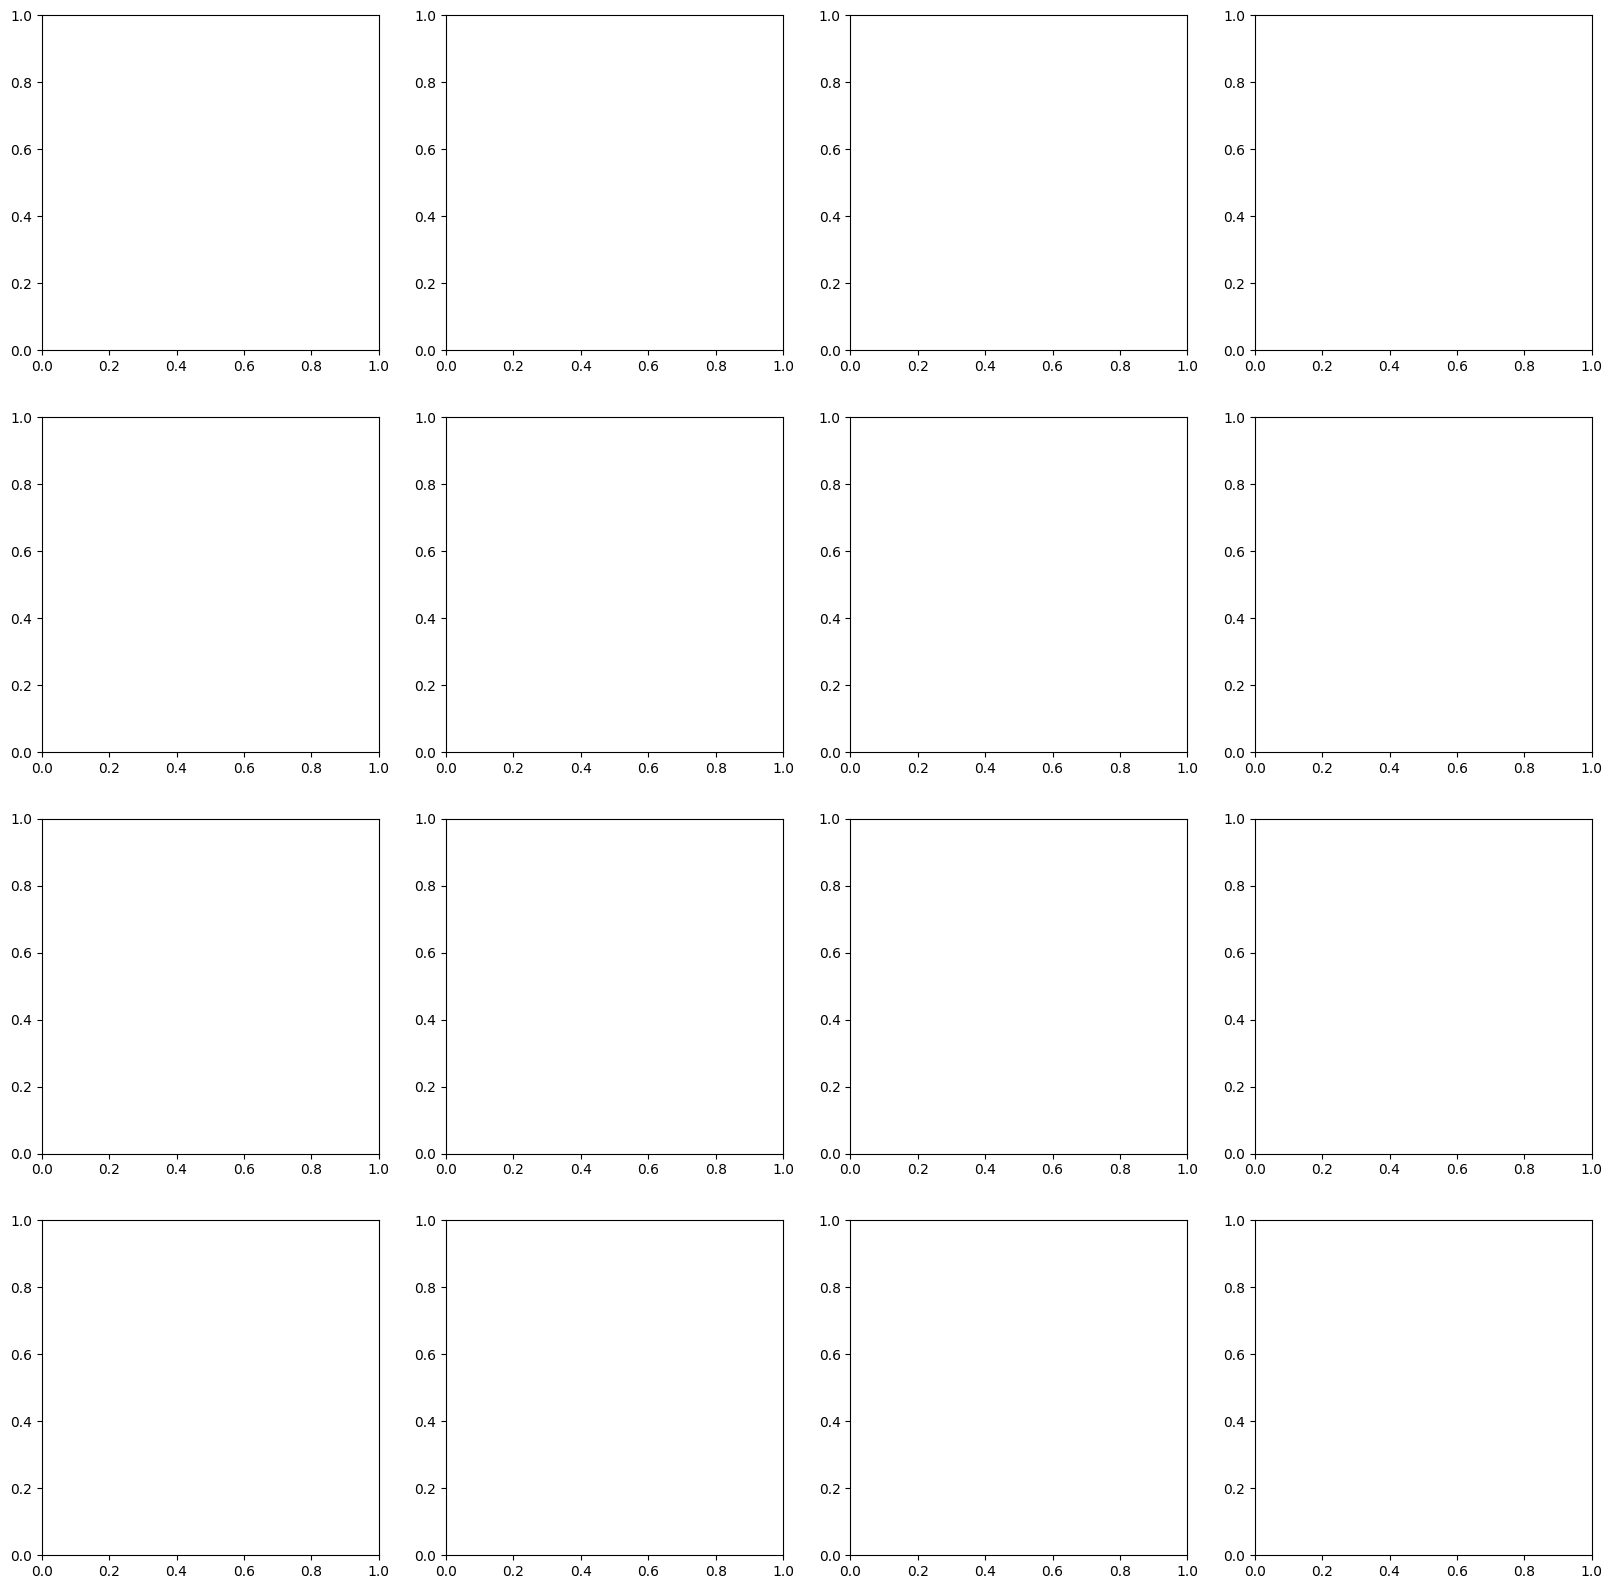

In [10]:
selected_classes = ['air_conditioner', 'car_horn', 'children_playing',
    'dog_bark', 'drilling', 'engine_idling',
    'gun_shot', 'jackhammer', 'siren', 'street_music']

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for i, category in enumerate(selected_classes):
    sample_row = df[df['class'] == category].sample(1).iloc[0]
    file_path = os.path.join(AUDIO_DIR, sample_row['slice_file_name'])
    
    # 1. Зареждане на аудиото
    y, sr = librosa.load(file_path, sr=22050)
    
    # 2. Генериране на Мел-спектрограма
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    
    # 3. Конвертиране в децибели (логаритмична скала)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # 4. Визуализация в съответната клетка
    ax = axes[i]
    img = librosa.display.specshow(
        mel_spec_db, 
        sr=sr, 
        x_axis='time', 
        y_axis='mel', 
        fmax=8000, 
        ax=ax, 
        cmap='magma' # 'magma' или 'viridis' са най-добри за спектрограми
    )
    
    # Оформяне на заглавието
    ax.set_title(category.replace('_', ' ').upper(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Време (s)')
    ax.set_ylabel('Честота (Hz)')

# Добавяне на обща цветова скала (Colorbar) отстрани
cbar = fig.colorbar(img, ax=axes.ravel().tolist(), format="%+2.0f dB", orientation='vertical', fraction=0.02, pad=0)
plt.suptitle("Акустични профили (Мел-спектрограми) на различни класове от ESC-50", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📊 Анализ на акустичните профили (Изводи за архитектурата)

Горната визуализация потвърждава фундаменталната хипотеза на проекта: **звуковата класификация може да бъде успешно решена като проблем на компютърното зрение**. Различните звукови източници генерират уникални и лесно разпознаваеми 2D визуални текстури (Мел-спектрограми), които Конволюционната невронна мрежа (CNN) може да научи.

От генерираната галерия могат да се направят няколко критични извода, които пряко влияят на избора на архитектура и предварителната обработка на данните:

#### 1. Времева концентрация на енергията (Обосноваване на 2-секундния прозорец)
При импулсивни или кратки звуци като **Dog (Куче)**, **Rooster (Петел)**, **Sneezing (Кихане)** и **Glass Breaking (Счупване на стъкло)** се забелязва, че почти цялата акустична енергия е концентрирана в първите 1.0 до 1.5 секунди. Останалата част от 5-секундния запис представлява абсолютна тишина (липса на пиксели).
* **Извод:** Това визуално доказва необходимостта от сегментация или изрязване до 2-секунден времеви прозорец. Подаването на цели 5-секундни записи би запълнило тензорите предимно с "нулева" информация, което би забавило обучението и би намалило ефективността на модела.

#### 2. Тонални и Хармонични звуци (Хоризонтални структури)
Звуците с ясна височина на тона формират консистентни хоризонтални модели:
* **Siren (Сирена):** Демонстрира перфектни, плавни вълнообразни линии, показващи модулацията на честотата във времето.
* **Crying Baby (Плачещо бебе) и Cow (Крава):** Показват ясно изразена хармонична структура (основен тон и множество успоредни обертонове над него).

#### 3. Широколентов шум (Плътни текстури)
Природните явления без специфичен тон разпръскват енергията си през целия честотен спектър:
* **Rain (Дъжд) и Sea Waves (Морски вълни):** Визуализират се като плътен "бял шум". Дъждът има по-равномерно покритие във високочестотния регистър, докато морските вълни показват характерни времеви пулсации на приливи и отливи.

#### 4. Импулсивни и Ритмични звуци (Вертикални структури)
Краткотрайните звукови удари се визуализират като резки вертикални колони:
* **Clapping (Пляскане) и Footsteps (Стъпки):** Показват серия от времеви импулси, разделени от кратки паузи. CNN архитектурата използва тези паузи, за да извлече "ритъма" на събитието като отличителна характеристика.
* **Crackling Fire (Пукащ огън):** Състои се от стотици микро-импулси (вертикални линии) с много висока плътност.

#### 5. Нискочестотни генератори
* **Helicopter (Хеликоптер) и Chainsaw (Резачка):** Енергията е силно концентрирана в най-долната част на спектрограмата (под 1024 Hz), придружена от специфична ритмична амплитудна модулация от двигателите.

**Заключение:** Голямото визуално разнообразие между класовете, както и специфичните времево-честотни форми (хоризонтални вълни спрямо вертикални импулси), потвърждават, че 2D Мел-спектрограмите са високоинформативен вход за дълбоки конволюционни мрежи.